In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("seattle-weather.csv")
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [4]:
modalities = df.columns
modalities = modalities.drop(["date", "weather"])
modalities = modalities.tolist()
modalities

['precipitation', 'temp_max', 'temp_min', 'wind']

In [5]:
rng = np.random.default_rng(42)
num_clients = 10

time_alpha = 1.0
mode_alpha = 10.0

partitions = {}
missing_modalities = set(modalities)

for client in range(num_clients):
    partitions[client] = pd.DataFrame(df.date)
    for m in modalities:
        partitions[client][m] = pd.Series()

client_alpha = rng.dirichlet([100000.0] * num_clients)
print(f"{client_alpha=}")
for i, row in enumerate(df.itertuples()):
    for m in modalities:
        client_dir = rng.dirichlet(client_alpha)
        client_idx = client_dir.argmax()
        # client_idx[0] *= client_mask[0]  # either 1 or 0, where 0 means this client cannot have this modality
        partitions[client_idx].loc[i, m] = getattr(row, m)

print("Done partitioning!")

client_alpha=array([0.10003685, 0.10017788, 0.09932518, 0.09998093, 0.09993521,
       0.1002187 , 0.09996139, 0.10008834, 0.10005711, 0.1002184 ])
Done partitioning!


In [6]:
partitions[1]

,date,precipitation,temp_max,temp_min,wind
0,2012-01-01,0.0,NaN,NaN,4.7
1,2012-01-02,NaN,NaN,2.8,NaN
2,2012-01-03,NaN,NaN,NaN,NaN
3,2012-01-04,20.3,NaN,NaN,NaN
4,2012-01-05,NaN,NaN,NaN,6.1
...,...,...,...,...,...
1456,2015-12-27,NaN,NaN,NaN,NaN
1457,2015-12-28,NaN,NaN,NaN,NaN
1458,2015-12-29,NaN,NaN,NaN,NaN
1459,2015-12-30,NaN,NaN,NaN,NaN


In [7]:
merged_partitions = []
for partition_idx, pdf in partitions.items():
    pdf = pdf.copy()
    pdf["partition"] = partition_idx
    merged_partitions.append(pdf)

merged_df = pd.concat(merged_partitions)
merged_df.head(100)

,date,precipitation,temp_max,temp_min,wind,partition
0,2012-01-01,NaN,NaN,NaN,NaN,0
1,2012-01-02,10.9,NaN,NaN,NaN,0
2,2012-01-03,NaN,NaN,NaN,NaN,0
3,2012-01-04,NaN,NaN,NaN,NaN,0
4,2012-01-05,NaN,NaN,2.8,NaN,0
...,...,...,...,...,...,...
95,2012-04-05,4.6,NaN,NaN,NaN,0
96,2012-04-06,NaN,NaN,NaN,2.6,0
97,2012-04-07,NaN,NaN,NaN,NaN,0
98,2012-04-08,NaN,NaN,NaN,NaN,0


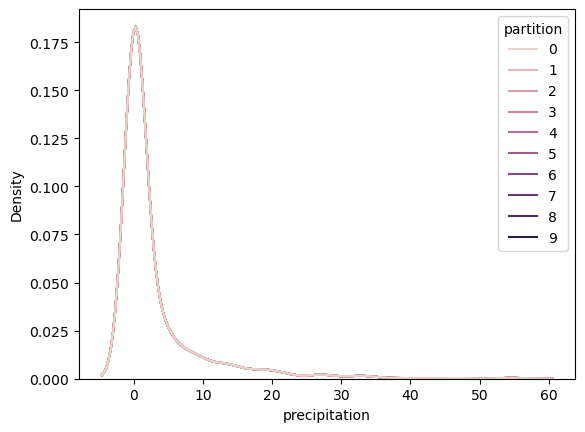

In [8]:
sns.kdeplot(merged_df, x="precipitation", hue="partition")
plt.show()

In [9]:
print(merged_df.head(100))

          date precipitation temp_max temp_min wind  partition
0   2012-01-01           NaN      NaN      NaN  NaN          0
1   2012-01-02          10.9      NaN      NaN  NaN          0
2   2012-01-03           NaN      NaN      NaN  NaN          0
3   2012-01-04           NaN      NaN      NaN  NaN          0
4   2012-01-05           NaN      NaN      2.8  NaN          0
..         ...           ...      ...      ...  ...        ...
95  2012-04-05           4.6      NaN      NaN  NaN          0
96  2012-04-06           NaN      NaN      NaN  2.6          0
97  2012-04-07           NaN      NaN      NaN  NaN          0
98  2012-04-08           NaN      NaN      NaN  NaN          0
99  2012-04-09           NaN     20.0      NaN  2.1          0

[100 rows x 6 columns]


In [10]:
merged_df.to_csv("merged_df.csv")

In [ ]:
def create_rng(seed=None):
    from numpy.random import Generator
    match seed:
        case Generator():
            return seed
        case int():
            return np.random.default_rng(seed)
        case None:
            return np.random.default_rng()
        case _:
            raise ValueError("Illegal value for argument `seed`.")

In [21]:
def generate_modality_mask(num_modalities, rng, decay_probs=[1.0, 0.5, 0.1, 0.01]):
    mask = np.zeros(num_modalities, dtype=int)
    remaining = set(range(num_modalities))
    for p in decay_probs:
        if not remaining:
            break
        idx = rng.choice(list(remaining))
        if rng.random() < p:
            mask[idx] = 1
            remaining.remove(idx)
    return mask

print(generate_modality_mask(4, create_rng(42)))

[1 1 0 0]


In [18]:
def partition_dataset(
    dataset: pd.DataFrame,
    num_nodes: int,
    time_alpha: float,
    modality_alpha: float,
    seed=None,
):
    rng = create_rng(seed)
    modalities = [col for col in dataset.columns if col not in ("date", "weather")]
    num_modalities = len(modalities)
    partitions = {}
    masks = {}

    for partition_idx in range(num_nodes):
        mask = generate_modality_mask(num_modalities, rng)
        masks[partition_idx] = mask
        # Apply mask to all rows in this partition
        part_df = dataset.copy()
        for m_idx, m in enumerate(modalities):
            if mask[m_idx] == 0:
                part_df[m] = np.nan
        partitions[partition_idx] = part_df

    return partitions, masks

# Example usage:
df = pd.read_csv('seattle-weather.csv')
num_nodes = 5
partitions, masks = partition_dataset(df, num_nodes, time_alpha=1.0, modality_alpha=1.0, seed=42)
print("Masks for each partition:")
for i, mask in masks.items():
    print(f"Partition {i}: {mask}")
display({i: part.head() for i, part in partitions.items()})

Masks for each partition:
Partition 0: [1 1 0 0]
Partition 1: [0 0 1 1]
Partition 2: [0 1 0 1]
Partition 3: [0 0 0 1]
Partition 4: [0 0 1 1]


{0:          date  precipitation  temp_max  temp_min  wind  weather
 0  2012-01-01            0.0      12.8       NaN   NaN  drizzle
 1  2012-01-02           10.9      10.6       NaN   NaN     rain
 2  2012-01-03            0.8      11.7       NaN   NaN     rain
 3  2012-01-04           20.3      12.2       NaN   NaN     rain
 4  2012-01-05            1.3       8.9       NaN   NaN     rain,
 1:          date  precipitation  temp_max  temp_min  wind  weather
 0  2012-01-01            NaN       NaN       5.0   4.7  drizzle
 1  2012-01-02            NaN       NaN       2.8   4.5     rain
 2  2012-01-03            NaN       NaN       7.2   2.3     rain
 3  2012-01-04            NaN       NaN       5.6   4.7     rain
 4  2012-01-05            NaN       NaN       2.8   6.1     rain,
 2:          date  precipitation  temp_max  temp_min  wind  weather
 0  2012-01-01            NaN      12.8       NaN   4.7  drizzle
 1  2012-01-02            NaN      10.6       NaN   4.5     rain
 2  2012-01-03

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('seattle-weather.csv')
modalities = [col for col in df.columns if col not in ("date", "weather")]
num_clients = 5
rng = np.random.default_rng(42)

# Dirichlet-based partitioning
partitions = {client: pd.DataFrame(df['date']) for client in range(num_clients)}
for client in partitions:
    for m in modalities:
        partitions[client][m] = pd.Series(dtype=float)

client_alpha = rng.dirichlet([100000.0] * num_clients)
for i, row in enumerate(df.itertuples()):
    for m in modalities:
        client_dir = rng.dirichlet(client_alpha)
        client_idx = client_dir.argmax()
        partitions[client_idx].loc[i, m] = getattr(row, m)

# Generate and apply a mask per partition

masks = {}
for client in partitions:
    mask = generate_modality_mask(len(modalities), rng)
    masks[client] = mask
    for m_idx, m in enumerate(modalities):
        if mask[m_idx] == 0:
            partitions[client][m] = np.nan

print("Masks for each partition:")
for client, mask in masks.items():
    print(f"Partition {client}: {mask}")

display({i: part.head() for i, part in partitions.items()})

Masks for each partition:
Partition 0: [0 0 1 1]
Partition 1: [1 0 1 0]
Partition 2: [1 0 0 0]
Partition 3: [0 0 1 0]
Partition 4: [1 1 0 1]


{0:          date  precipitation  temp_max  temp_min  wind
 0  2012-01-01            NaN       NaN       NaN   4.7
 1  2012-01-02            NaN       NaN       NaN   4.5
 2  2012-01-03            NaN       NaN       7.2   NaN
 3  2012-01-04            NaN       NaN       NaN   NaN
 4  2012-01-05            NaN       NaN       NaN   NaN,
 1:          date  precipitation  temp_max  temp_min  wind
 0  2012-01-01            NaN       NaN       5.0   NaN
 1  2012-01-02            NaN       NaN       NaN   NaN
 2  2012-01-03            NaN       NaN       NaN   NaN
 3  2012-01-04            NaN       NaN       NaN   NaN
 4  2012-01-05            NaN       NaN       NaN   NaN,
 2:          date  precipitation  temp_max  temp_min  wind
 0  2012-01-01            NaN       NaN       NaN   NaN
 1  2012-01-02            NaN       NaN       NaN   NaN
 2  2012-01-03            0.8       NaN       NaN   NaN
 3  2012-01-04            NaN       NaN       NaN   NaN
 4  2012-01-05            NaN       N

In [ ]:
merged_df = pd.concat([partitions[i].assign(partition=i) for i in partitions], ignore_index=True)

merged_df.to_csv("merged_df.csv", index=False)
print(f"merged_df saved to merged_df.csv, shape: {merged_df.shape}")
merged_df.head()

merged_df saved to merged_df.csv, shape: (7305, 6)


,date,precipitation,temp_max,temp_min,wind,partition
0,2012-01-01,NaN,NaN,NaN,4.7,0
1,2012-01-02,NaN,NaN,NaN,4.5,0
2,2012-01-03,NaN,NaN,7.2,NaN,0
3,2012-01-04,NaN,NaN,NaN,NaN,0
4,2012-01-05,NaN,NaN,NaN,NaN,0
